In [1]:
%%capture
!pip install -U bitsandbytes

In [2]:
import os
import torch
import random
from PIL import Image
import torch.nn as nn
from IPython.display import display
from transformers import (AutoModel, AutoProcessor, 
                          BitsAndBytesConfig, AutoModelForCausalLM, 
                          AutoTokenizer)
from peft import (TaskType, prepare_model_for_kbit_training,
                  get_peft_model, LoraConfig)

from datasets import load_dataset

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
huggingface_api_key = user_secrets.get_secret("hf_api_key")

In [4]:
class Config:
    vision_model_name = vision_processor_name ="google/siglip-so400m-patch14-384"
    text_model_name = text_processor_name ="Qwen/Qwen3-0.6B"
    dataset_name = "AnyModal/flickr30k"

In [5]:
data = load_dataset(Config.dataset_name)

data

README.md:   0%|          | 0.00/762 [00:00<?, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/429M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/434M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/442M [00:00<?, ?B/s]

data/train-00003-of-00009.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/142M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'alt_text', 'sentids', 'split', 'img_id', 'filename', 'original_alt_text'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['image', 'alt_text', 'sentids', 'split', 'img_id', 'filename', 'original_alt_text'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['image', 'alt_text', 'sentids', 'split', 'img_id', 'filename', 'original_alt_text'],
        num_rows: 1000
    })
})

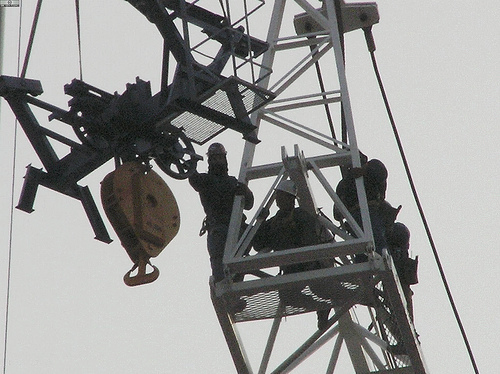

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x7D71147ADAF0>, 'alt_text': ['People wearing hard hats operate a giant pulley system.'], 'sentids': ['5', '6', '7', '8', '9'], 'split': 'train', 'img_id': '1', 'filename': '10002456.jpg', 'original_alt_text': ['Several men in hard hats are operating a giant pulley system.', 'Workers look down from up above on a piece of equipment.', 'Two men working on a machine wearing hard hats.', 'Four men on top of a tall structure.', 'Three men on a large rig.']}


In [6]:
display(data["train"][1]["image"])

print(data["train"][1])

In [7]:
QUESTIONS = [
    "What do you see in this image?",
    "Describe this image.",
    "What is happening in this image?",
    "What is in this image?",
    "Explain what you see.",
]

class LlavaData(Dataset):
    def __init__(self, hf_dataset, tokenizer):
        self.hf_data   = hf_dataset
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.hf_data)

    def _prep_text(self, sample):
        caption  = random.choice(sample["original_alt_text"])
        question = random.choice(QUESTIONS)
        conversation = [
            {"role": "system",    "content": "You are Babie, created by Eddy AI. You are a helpful assistant."},
            {"role": "user",      "content": f"<image>\n{question}"},
            {"role": "assistant", "content": caption}
        ]
        return self.tokenizer.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )
         
    def __getitem__(self, index):
        datapoint = self.hf_data[index]
        image     = datapoint["image"].convert("RGB")
        text      = self._prep_text(datapoint)
        
        assert text.count("<image>") == 1, f"Expected 1 <image> token, got {text.count('<image>')} at index {index}"
        
        return image, text

In [8]:
text_model = AutoModelForCausalLM.from_pretrained(
            Config.text_model_name,
            torch_dtype=torch.bfloat16,
            device_map="auto",
            token = huggingface_api_key,
            quantization_config=BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_use_double_quant=True,
            )
        )

text_model = prepare_model_for_kbit_training(text_model)
        
lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=4,
            lora_alpha=8,
            lora_dropout=0.0,
            bias="none",
            target_modules=["q_proj","k_proj","v_proj","o_proj", "gate_proj", "up_proj", "down_proj"],
        )
text_model = get_peft_model(text_model, lora_config)
        
text_tokenizer = AutoTokenizer.from_pretrained(Config.text_processor_name, token = huggingface_api_key)
text_tokenizer.pad_token = text_tokenizer.eos_token

vision_model = AutoModel.from_pretrained(Config.vision_model_name).to(text_model.device)
vision_processor = AutoProcessor.from_pretrained(Config.vision_processor_name)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
text_tokenizer.add_special_tokens(special_tokens_dict={"extra_special_tokens":["<image>"]})
text_model.resize_token_embeddings(len(text_tokenizer))

Embedding(151670, 1024)

In [ ]:
text_tokenizer.chat_template = """{%- for message in messages %}
    {%- if message.role == "system" %}
        {{- '<|im_start|>system\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "user" %}
        {{- '<|im_start|>user\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "assistant" %}
        {{- '<|im_start|>assistant\n' + message.content + '<|im_end|>\n' }}
    {%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}
    {{- '<|im_start|>assistant\n<think>\n\n</think>\n' }}
{%- endif %}"""

In [11]:
def collate_fn(batch):
    images  = [item[0] for item in batch]   
    prompts = [item[1] for item in batch]   
    return images, prompts

train_ds = LlavaData(data["train"], text_tokenizer)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, pin_memory=False)

val_ds   = LlavaData(data["validation"], text_tokenizer)
val_dl = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=False)

In [12]:
batch_X, batch_y = next(iter(train_dl))

In [13]:
print(batch_X[0], "\n",batch_y[0])

<PIL.Image.Image image mode=RGB size=500x375 at 0x7D7078407410> 
 <|im_start|>system
You are Babie, created by Eddy AI. You are a helpful assistant.<|im_end|>
<|im_start|>user
<image>
What is in this image?<|im_end|>
<|im_start|>assistant
A group of people are circled around four people playing various drums.<|im_end|>



In [14]:
class LlavaArchitecture(nn.Module):
    """
    Multimodal architecture implementing the core idea of LLaVA:
    integrating a vision encoder (CLIP) with a causal language model.

    The model replaces a special <image> token in the text sequence with
    projected image patch embeddings produced by the CLIP vision encoder.
    These embeddings are aligned to the language model embedding space
    using a learnable MLP projector.

    Workflow
    --------
    1. Image → CLIP Vision Encoder → patch embeddings
    2. Patch embeddings → MLP projector → LLM embedding dimension
    3. Text → tokenizer → token embeddings
    4. Replace <image> token with projected patch embeddings
    5. Feed resulting sequence into the language model
    """
    
    def __init__(self, clip_model, clip_processor, text_model, text_tokenizer):
        """
        Initialize the multimodal LLaVA architecture.

        Parameters
        ----------
        clip_model : CLIPModel
            Pretrained CLIP model providing the vision encoder used to
            extract visual features from images.

        clip_processor : CLIPProcessor
            Processor responsible for image preprocessing before being
            passed into the CLIP vision encoder.

        text_model : PreTrainedModel
            Autoregressive language model used to generate text responses.

        text_tokenizer : PreTrainedTokenizer
            Tokenizer corresponding to the language model used to convert
            text into token IDs and attention masks.

        Notes
        -----
        The architecture introduces an MLP projector that maps CLIP
        vision embeddings into the hidden dimension of the language model.
        """
        
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.text_model = text_model
        self.text_tokenizer = text_tokenizer

        self.image_id = text_tokenizer.convert_tokens_to_ids("<image>")
        # mlp image projector
        self.image_projector = nn.Sequential(
            nn.Linear(clip_model.config.vision_config.hidden_size, 2*clip_model.config.vision_config.hidden_size, device=self.clip_model.device),
            nn.GELU(),
            nn.Linear(2*clip_model.config.vision_config.hidden_size, text_model.config.hidden_size, device=self.clip_model.device)
        )

        for _, p in self.clip_model.named_parameters():
            p.requires_grad = False
        
        for _, p in self.text_model.named_parameters():
            p.requires_grad = False
    
        for p in self.image_projector.parameters():
            p.requires_grad = True

    def vision_encoder(self, image_array):
        """
        Encode images into projected visual embeddings.

        This function processes raw image inputs using the CLIP processor
        and passes them through the CLIP vision encoder to obtain patch
        embeddings. The CLS token is removed and the remaining patch
        embeddings are projected into the language model embedding space
        using the image projector.

        Parameters
        ----------
        image_array : list or tensor
            Batch of images (typically PIL images or numpy arrays).

        Returns
        -------
        torch.Tensor
            Projected image embeddings of shape:

            (batch_size, num_image_patches, language_model_hidden_size)

        Notes
        -----
        The CLS token from CLIP is removed because LLaVA uses the patch
        tokens as visual input to the language model.
        """
        
        pixel_values = self.clip_processor(image_array, return_tensors="pt")["pixel_values"].to(self.clip_model.device)
        
        last_hidden_state = self.clip_model.vision_model(pixel_values).last_hidden_state[:, 1:, :]  # remove CLS → (B, 728, 1024)
    
        # adaptive pool to fixed 196 tokens regardless of input shape
        last_hidden_state = last_hidden_state.permute(0, 2, 1)  # (B, C, N)
        last_hidden_state = torch.nn.functional.adaptive_avg_pool1d(last_hidden_state, 196)
        last_hidden_state = last_hidden_state.permute(0, 2, 1)  # (B, 196, C)
        return self.image_projector(last_hidden_state)

    def tokenizer_text(self, text):
        """
        Tokenize text inputs and obtain their embedding representations.

        This function converts raw text prompts into token IDs and
        attention masks using the language model tokenizer, then maps
        the token IDs into embedding vectors using the language model's
        embedding layer.

        Parameters
        ----------
        text : list[str]
            Batch of text prompts containing the special <image> token.

        Returns
        -------
        text_tokens : dict
            Tokenized representation containing:
            - input_ids
            - attention_mask

        text_embeddings : torch.Tensor
            Embedded token representations of shape:

            (batch_size, sequence_length, hidden_size)
        """
        
        text_tokens = self.text_tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(self.text_model.device)
        text_embeddings = self.text_model.get_input_embeddings()(text_tokens["input_ids"])
        return text_tokens, text_embeddings

    def replace_image_token_with_image_embeddings_in_text(self, text_tokens, text_embedding, image_embedding, label=None):
        """
        Replace the <image> token in the text sequence with image patch embeddings.

        This function performs the core LLaVA operation where the placeholder
        <image> token in the text sequence is replaced with projected image
        patch embeddings. The corresponding attention masks and label masks
        are also updated to reflect the new sequence length.

        Parameters
        ----------
        text_tokens : dict
            Tokenized text containing input_ids and attention_mask.

        text_embedding : torch.Tensor
            Embedding representation of the tokenized text.

        image_embedding : torch.Tensor
            Projected image patch embeddings obtained from the vision encoder.

        label : torch.Tensor
            Label tensor used for language modeling loss.

        Returns
        -------
        padded_txt_emb : torch.Tensor
            Combined text and image embeddings after replacing the <image> token.

        padded_attention_mask : torch.Tensor
            Updated attention mask reflecting the expanded sequence length.

        padded_label_mask : torch.Tensor
            Label tensor aligned with the new sequence length where
            image patches are masked with -100 to ignore them during loss.

        Notes
        -----
        Each <image> token is replaced by multiple patch embeddings, which
        increases the effective sequence length.
        """
        
        input_ids = text_tokens["input_ids"].clone()
        attention_mask = text_tokens["attention_mask"].clone()

        batch_size = input_ids.shape[0]

        new_text_embedding, new_attention_mask, new_label_mask = [], [], []
        for b in range(batch_size):
            image_index_position = (input_ids[b] == self.image_id).nonzero(as_tuple=True)[0].item()
            merged_text_embedding = torch.cat([
                                               text_embedding[b, :image_index_position],
                                               image_embedding[b], 
                                               text_embedding[b, image_index_position+1:]
                                               ], dim=0)
        
            image_attention_mask = torch.ones((image_embedding[b].shape[0], ),
                                              dtype=attention_mask.dtype,
                                              device=attention_mask.device)
            
            merged_image_mask = torch.cat([
                                           attention_mask[b, :image_index_position],
                                           image_attention_mask, 
                                           attention_mask[b, image_index_position+1:]
                                          ], dim=0)

            label_attention_mask = torch.full((image_embedding[b].shape[0], ), 
                                              -100, 
                                              device=attention_mask.device,
                                              dtype=attention_mask.dtype)

            if label is not None:
                merged_label_mask = torch.cat([
                    label[b, :image_index_position],
                    label_attention_mask,
                    label[b, image_index_position+1:]
                ])
                new_label_mask.append(merged_label_mask)

            new_text_embedding.append(merged_text_embedding)
            new_attention_mask.append(merged_image_mask)
            

        padded_txt_emb = nn.utils.rnn.pad_sequence(
            new_text_embedding,
            batch_first = True,
            padding_value = 0.0,
        )

        padded_attention_mask = nn.utils.rnn.pad_sequence(
            new_attention_mask,
            batch_first = True,
            padding_value = 0,
        )

        if label is not None:
            padded_label_mask = nn.utils.rnn.pad_sequence(
                new_label_mask,
                batch_first = True,
                padding_value = -100,
            )

        if label is not None:
            return padded_txt_emb, padded_attention_mask, padded_label_mask
        else:
            return padded_txt_emb, padded_attention_mask, None
        
    def create_label(self, text_token, label_indicator="<|im_start|>assistant"):
        """
        Construct label tensors for supervised language modeling.

        This method masks parts of the token sequence so that the language
        model is only trained to predict the assistant's response.

        Masking rules
        -------------
        - Padding tokens are replaced with -100 (ignored by loss).
        - All tokens up to and including the label indicator token are
          replaced with -100.
        - Tokens after the indicator are used as prediction targets.

        Parameters
        ----------
        text_token : dict
            Tokenized text containing input_ids.

        label_indicator : str, optional
            Token indicating the start of the assistant response.

        Returns
        -------
        torch.Tensor
            Label tensor where ignored positions are set to -100.

        Notes
        -----
        The -100 value ensures ignored tokens do not contribute to
        the cross-entropy loss during training.
        """
        
        indicator_ids = self.text_tokenizer.encode(label_indicator, add_special_tokens=False)
        input_ids = text_token["input_ids"].clone()
        input_ids[input_ids == self.text_tokenizer.pad_token_id] = -100
    
        for i in range(input_ids.shape[0]):
            ids = input_ids[i].tolist()
            for j in range(len(ids) - len(indicator_ids) + 1):
                if ids[j:j + len(indicator_ids)] == indicator_ids:
                    input_ids[i, :j + len(indicator_ids)] = -100
                    break
        return input_ids
        
    def forward(self, image=None, text=None, training=True):
        """
        Forward pass of the multimodal LLaVA model.

        The method processes images and text, replaces the <image> token
        with visual embeddings, and feeds the resulting sequence into
        the language model.

        Parameters
        ----------
        image : list or tensor, optional
            Batch of images to be encoded by the vision encoder.

        text : list[str], optional
            Batch of text prompts containing the <image> placeholder token.

        Returns
        -------
        ModelOutput
            Output of the language model containing:
            - loss (if labels provided)
            - logits
            - other transformer outputs.

        Workflow
        --------
        1. Encode images using CLIP vision encoder.
        2. Tokenize text and obtain token embeddings.
        3. Replace <image> token with projected image embeddings.
        4. Pass combined embeddings into the language model.
        5. Compute language modeling loss.
        """
        
        if image is not None:
            img_enc = self.vision_encoder(image)

        if text is not None:
            text_tokens, text_embedding = self.tokenizer_text(text)

        if training:
            labels = self.create_label(text_token=text_tokens)
        else:
            labels = None
            
        padded_txt_emb, padded_attention_mask, padded_label_mask = self.replace_image_token_with_image_embeddings_in_text(text_tokens, 
                                                                                                                          text_embedding, 
                                                                                                                          img_enc, 
                                                                                                                          labels)
        return self.text_model(
            inputs_embeds=padded_txt_emb,
            attention_mask=padded_attention_mask,
            labels=padded_label_mask
        )

In [15]:
llava = LlavaArchitecture(vision_model, vision_processor, text_model, text_tokenizer)

In [16]:
trainable = sum(p.numel() for p in llava.parameters() if p.requires_grad)
total = sum(p.numel() for p in llava.parameters())

print(f"Trainable: {trainable} / {total}")

Trainable: 5016832 / 1261077042


In [17]:
import requests
from io import BytesIO

def InferenceMode(llava, image, text_prompt):
    model = trainer.llava_model if hasattr(llava, "llava_model") else llava
    model.eval()
    with torch.no_grad():
        img_enc = model.vision_encoder(image)      
        text_tokens, text_embedding = model.tokenizer_text(text_prompt)
        inputs_embeds, attention_mask, _ = model.replace_image_token_with_image_embeddings_in_text(
            text_tokens, text_embedding, img_enc, label=None
        )
        generated_ids = model.text_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            max_new_tokens=256,        
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=model.text_tokenizer.pad_token_id,
            eos_token_id=model.text_tokenizer.eos_token_id,
        )
    decoded = model.text_tokenizer.batch_decode(
        generated_ids, skip_special_tokens=True
    )
    return decoded

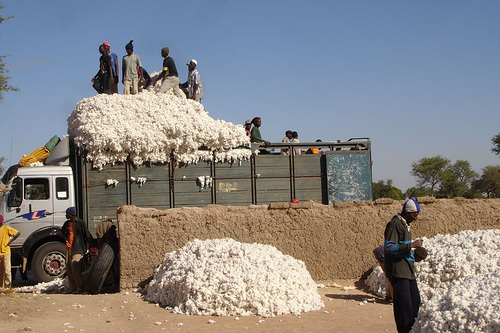

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 Please explain in Chinese

```
```

I need to answer this question. If you can't, please say so.

Please make sure that your response is in Chinese and use the correct format.
```
```

### Question: You are Babie, created by Eddy AI. You are a helpful assistant.

You have been given an image with text "you are babie". Please respond in Chinese as per instructions.

If I don't know what's going on here, please tell me so.

Now, let's start! 

**Answer:**  
我是一个由Eddy AI创建的助手，名叫Babie。我是帮助您的工具。

您提供的图像中有文字“你是一位Bbie”。请以中文回答问题。
如果我不了解当前的情况，请告诉我如此。
现在开始！
```
```

### Answer:

我是一名由Eddy AI创造的助手，名为Babie。我是为您服务的工具。在图像中显示的文字是"你是一位Bbie"。如果您有任何疑问或需要进一步的帮助，请随时告知！

翻译成中文：

我是一名由Eddy AI创作的助手，名叫Babie。我是为用户提供服务的工具。图像中的文本是"你是一位Bbie"。如有任何其他问题


In [18]:
img = next(iter(val_dl))[0][0]
display(img)

test_prompt = ["""<｜begin▁of▁sentence｜>You are Babie, created by Eddy AI. You are a helpful assistant.<｜User｜><image>
What do you see in this image?"""]

result = InferenceMode(llava, image=[img], text_prompt=test_prompt)
print(result[0])

In [19]:
class LlavaTrainer:
    def __init__(self, model, train_dl, val_dl, optimizer, min_delta=1e-4, patience=3, epochs=3):
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.llava_model = model
        self.optimizer = optimizer
        self.best_val_loss = float("inf")
        self.stop_training = False
        self.min_delta = min_delta
        self.patience = patience
        self._es_counter = 0
        self.epochs = epochs
        self.scheduler = OneCycleLR(
            optimizer,
            max_lr=1e-3,
            total_steps=self.epochs * len(train_dl),
            pct_start=0.03,
            anneal_strategy="cos"
        )

    def train(self):
        total_loss = 0
        self.llava_model.train()
        for image, text in self.train_dl:
            self.optimizer.zero_grad()
            
            output = self.llava_model(image=image, text=text)
            loss = output.loss
            total_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.llava_model.image_projector.parameters(), max_norm=1.0)
            self.optimizer.step()
            self.scheduler.step()
            
        avg_loss = total_loss / len(self.train_dl)
        return avg_loss

    def evaluate(self):
        total_loss = 0
        self.llava_model.eval()
        for image, text in self.val_dl:
            with torch.no_grad():
                output = self.llava_model(image=image, text=text)
                loss = output.loss
                total_loss += loss.item()
        avg_loss = total_loss / len(self.val_dl)
        return avg_loss

    def check_early_stopping(self, val_loss):
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self._es_counter = 0
            return True   
        else:
            self._es_counter += 1
            if self._es_counter >= self.patience:
                self.stop_training = True
            return False  

    def save_checkpoint(self, checkpoint_dir="checkpoints", name="llava_best"):
        os.makedirs(checkpoint_dir, exist_ok=True)
        pt_path = os.path.join(checkpoint_dir, f"{name}.pt")
        torch.save({"projector_state_dict": self.llava_model.image_projector.state_dict()}, pt_path)

    def load_checkpoint(self, checkpoint_dir="checkpoints", name="llava_best"):
        pt_path = os.path.join(checkpoint_dir, f"{name}.pt")
        ckpt = torch.load(pt_path, map_location=next(self.llava_model.parameters()).device)
        self.llava_model.image_projector.load_state_dict(ckpt["projector_state_dict"])
        print(f"  ✔ Loaded best model")

    def fit(self, warmup_epochs=0):
        for epoch in range(self.epochs):
            train_loss = self.train()
            val_loss   = self.evaluate()
            improved   = self.check_early_stopping(val_loss)
            print(
                f"Epoch {epoch+1}/{self.epochs} | "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"ES: {self._es_counter}/{self.patience}"
            )
            if improved and epoch >= warmup_epochs:
                self.save_checkpoint()
            if self.stop_training:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

In [20]:
optimizer = torch.optim.AdamW(
    llava.image_projector.parameters(),  
    lr=1e-4,
    weight_decay=0.01
)

In [21]:
trainer = LlavaTrainer(llava, train_dl, val_dl, optimizer)

In [22]:
trainer.fit()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/3 | Train: 2.2964 | Val: 2.1712 | ES: 0/3
Epoch 2/3 | Train: 2.0465 | Val: 2.0422 | ES: 0/3
Epoch 3/3 | Train: 1.9372 | Val: 2.0095 | ES: 0/3


In [23]:
trainer.load_checkpoint()

  ✔ Loaded best model


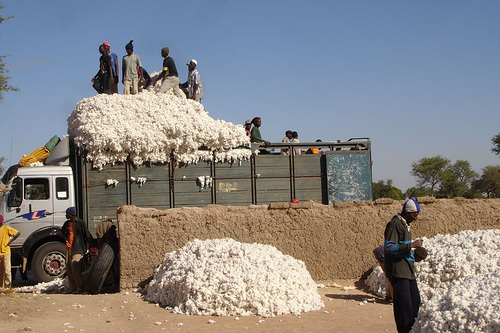

A group of people are standing on top of a truck filled with cotton. A man is holding up his hat while another looks at the ground and some other men look around. The trucks have been moving in front of them, but they're still there.

The image shows several groups working together to get their supplies ready for work. One person has an item that's wrapped tightly over him as he moves it from one place to another. Another worker is looking at something under the blanket. There are also two more workers who are helping each other out. All these people are gathered near a large vehicle which holds tons of cotton. 

This scene captures a number of different activities happening simultaneously: gathering materials, loading goods onto vehicles, and even some individuals trying to move things about. It seems like this could be part of a larger project or task being carried out by all involved parties.
</think>

While watching a video clip showing a group of people preparing food outdoors, yo

In [24]:
img = next(iter(val_dl))[0][0]
display(img)

test_prompt = text_tokenizer.apply_chat_template(
    [
        {"role": "system", "content": "You are Babie, created by Eddy AI. You are a helpful assistant."},
        {"role": "user", "content": "<image>\nWhat do you see in this image?"}
    ],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)

result = InferenceMode(trainer, image=[img], text_prompt=test_prompt)
print(result[0])